# Social Media Engagement Analytics Using Python

### Targetting for data cleaning, transformation, NumPy/Pandas operations, exploratory data analysis, visualizations, and generating insights from massive volumes of engagement data

### Import neccessary python libraries

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Task 1 : Data import and setup

In [51]:
df = pd.read_csv(r"E:\ENTRI-Data_Analystics\Python\DA Assignments\social_media_engagement_5000.csv")

In [52]:
df.head(5)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [53]:
df.shape

(5000, 19)

In [54]:
df.info() # info gives the Data type and null value details

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   str    
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   str    
 16  sentiment         4850 non-null   str    
 17  hashta

In [55]:
# Convert date columns to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'])
df.dtypes

C:\Users\AISWARYA\AppData\Local\Temp\ipykernel_2844\3915338088.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
dtype: object

In [56]:
# NumPy arrays for basic array operations
likesArray = df['likes'].to_numpy()
likesArray

#since the numerical columns likes, comments, shares have missing values doing the numpy operations won't given a proper answer. 
# np.mean(likesArray) gives np.float64(nan) 
# if need to avoid the missing we can use np.nanmean() functions
# performing numpy operations on follower_count since no missing values
followercountArray = df['follower_count'].to_numpy()
followercountArray
followerMean = np.mean(followercountArray)
followerMax = np.max(followercountArray)
followerVarience = np.std(followercountArray)
print(f"Mean of follower count : {followerMean}")
print(f"Max of follower count : {followerMax}")
print(f"Varience of follower count : {followerVarience}")

Mean of follower count : 393698.2248
Max of follower count : 799533
Varience of follower count : 230904.7905914017


In [57]:
df = df.rename(str.title, axis = 'columns') # standarize the coulmn names

In [58]:
df

,User_Id,Age,Gender,Country,Post_Id,Post_Type,Post_Category,Likes,Comments,Shares,Watch_Time_Sec,Impression_Count,Posted_At,Follower_Count,Is_Verified,Device_Type,Sentiment,Hashtags,Engagement_Rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


## Task 2 : Data Cleaning

### Cleaning missing values

In [59]:
# columns have missing values: age, gender, likes, comments, shares, sentiment.
df.isna().sum()

User_Id               0
Age                 150
Gender              150
Country               0
Post_Id               0
Post_Type             0
Post_Category         0
Likes               150
Comments            150
Shares              150
Watch_Time_Sec        0
Impression_Count      0
Posted_At             0
Follower_Count        0
Is_Verified           0
Device_Type           0
Sentiment           150
Hashtags              0
Engagement_Rate       0
dtype: int64

In [60]:
df['Age'].describe()

count    4850.000000
mean       38.454021
std        14.912381
min        13.000000
25%        26.000000
50%        38.000000
75%        51.000000
max        64.000000
Name: Age, dtype: float64

In [61]:
df['Age'] = df['Age'].fillna(df['Age'].median().round())
df.isna().sum()

User_Id               0
Age                   0
Gender              150
Country               0
Post_Id               0
Post_Type             0
Post_Category         0
Likes               150
Comments            150
Shares              150
Watch_Time_Sec        0
Impression_Count      0
Posted_At             0
Follower_Count        0
Is_Verified           0
Device_Type           0
Sentiment           150
Hashtags              0
Engagement_Rate       0
dtype: int64

In [62]:
df['Gender'].unique()

<ArrowStringArray>
['Female', 'Male', 'Other', nan]
Length: 4, dtype: str

In [63]:
df['Gender'].describe(include = "object")

count     4850
unique       3
top       Male
freq      1699
Name: Gender, dtype: object

In [64]:
df['Gender'] = df['Gender'].fillna( df['Gender'].mode()[0]) # fill with most frequent entry

In [65]:
df.isna().sum()

User_Id               0
Age                   0
Gender                0
Country               0
Post_Id               0
Post_Type             0
Post_Category         0
Likes               150
Comments            150
Shares              150
Watch_Time_Sec        0
Impression_Count      0
Posted_At             0
Follower_Count        0
Is_Verified           0
Device_Type           0
Sentiment           150
Hashtags              0
Engagement_Rate       0
dtype: int64

In [66]:
# filling likes column
likesMedian = df.groupby('Post_Type')['Likes'].transform('median') # this is to get the median of likes depending on post type for data integrity
df['Likes'] = df['Likes'].fillna(likesMedian.round())
likesMedian

0       10226.0
1        9983.5
2       10008.5
3       10008.5
4       10226.0
         ...   
4995    10174.0
4996     9983.5
4997    10008.5
4998    10174.0
4999    10008.5
Name: Likes, Length: 5000, dtype: float64

In [67]:

# filling comments column
df['Post_Category'].unique() # filling based on post category 
commentsMedian = df.groupby('Post_Category')['Comments'].transform('median')
df['Comments'] = df['Comments'].fillna(commentsMedian.round())

# filling share count
shareMedian = df.groupby('Post_Category')['Shares'].transform('median')
df['Shares'] = df['Shares'].fillna(shareMedian.round())

In [68]:
df.isna().sum()

User_Id               0
Age                   0
Gender                0
Country               0
Post_Id               0
Post_Type             0
Post_Category         0
Likes                 0
Comments              0
Shares                0
Watch_Time_Sec        0
Impression_Count      0
Posted_At             0
Follower_Count        0
Is_Verified           0
Device_Type           0
Sentiment           150
Hashtags              0
Engagement_Rate       0
dtype: int64

In [69]:
# filling sentiment count
df['Sentiment'].describe()

count         4850
unique           3
top       positive
freq          2363
Name: Sentiment, dtype: object

In [70]:
df['Sentiment'].unique()

<ArrowStringArray>
['negative', 'positive', 'neutral', nan]
Length: 4, dtype: str

In [71]:
sentimentMode = df.groupby('Post_Category')['Sentiment'].transform(lambda x: x.mode()[0])
df['Sentiment'] = df['Sentiment'].fillna(sentimentMode)

In [72]:
df.isna().sum()

User_Id             0
Age                 0
Gender              0
Country             0
Post_Id             0
Post_Type           0
Post_Category       0
Likes               0
Comments            0
Shares              0
Watch_Time_Sec      0
Impression_Count    0
Posted_At           0
Follower_Count      0
Is_Verified         0
Device_Type         0
Sentiment           0
Hashtags            0
Engagement_Rate     0
dtype: int64

### Duplicate handling

In [73]:
df['Post_Id'].duplicated().sum()

np.int64(9)

In [74]:
df.drop_duplicates(subset = 'Post_Id',inplace = True)

In [75]:
df.shape

(4991, 19)

### Data formatting

In [76]:
df['Gender'].unique() 
# since the values are proper no formating needed

<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [77]:
# fixing datatypes
df[['Age','Likes','Shares','Comments']] = df[['Age','Likes','Shares','Comments']].astype(int)


In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 4991 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_Id           4991 non-null   int64         
 1   Age               4991 non-null   int64         
 2   Gender            4991 non-null   str           
 3   Country           4991 non-null   str           
 4   Post_Id           4991 non-null   int64         
 5   Post_Type         4991 non-null   str           
 6   Post_Category     4991 non-null   str           
 7   Likes             4991 non-null   int64         
 8   Comments          4991 non-null   int64         
 9   Shares            4991 non-null   int64         
 10  Watch_Time_Sec    4991 non-null   int64         
 11  Impression_Count  4991 non-null   int64         
 12  Posted_At         4991 non-null   datetime64[us]
 13  Follower_Count    4991 non-null   int64         
 14  Is_Verified       4991 non-null   bool  

In [79]:
# ■	Correct unrealistic values in likes, comments, shares - Considering these as actual content reach, keeping the outliers as it is for plots
#IQR method - to showcase the use
# Q1 = df['likes'].quantile(.25)
# Q3 = df['likes'].quantile(.75)
# IQR = Q3 - Q1
# lowerLimit = Q1 -1.5*IQR
# upperLimit = Q3+ 1.5*IQR
# lowerLimit, upperLimit
# get new df with values excluding this outlier for likes column
#df[(df['likes'] > lowerLimit) & (df['likes'] < upperLimit)]

In [80]:
#Standardize categories
df['Gender'] = df['Gender'].str.strip().str.title()
df['Sentiment'] = df['Sentiment'].str.strip().str.title()
df['Country'] = df['Country'].str.strip().str.title()
df['Post_Type'] = df['Post_Type'].str.strip().str.title()
df['Post_Category'] = df['Post_Category'].str.strip().str.title()
df['Device_Type'] = df['Device_Type'].str.strip().str.title()

### Feature Cleaning

In [81]:
df['Hashtags'].value_counts()
# Extract hashtag count
df['Hashtags Count'] = df['Hashtags'].str.split().str.len()

In [82]:
df

,User_Id,Age,Gender,Country,Post_Id,Post_Type,Post_Category,Likes,Comments,Shares,Watch_Time_Sec,Impression_Count,Posted_At,Follower_Count,Is_Verified,Device_Type,Sentiment,Hashtags,Engagement_Rate,Hashtags Count
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,1
2,86820,32,Female,Uk,109864,Text,Food,4862,344,955,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,Uk,449706,Image,Fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,Video,Education,16210,2013,1837,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,2
4996,22100,38,Other,Uae,677076,Reel,Education,16924,2734,1583,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63,Female,Usa,273595,Text,Travel,13487,1478,167,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,Video,Fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3


In [83]:
df['Sentiment'].unique() # Clean sentiment labels done at line 153

<ArrowStringArray>
['Negative', 'Positive', 'Neutral']
Length: 3, dtype: str

## Task 3 — Data Exploration using Pandas

In [84]:
df.head(5)

,User_Id,Age,Gender,Country,Post_Id,Post_Type,Post_Category,Likes,Comments,Shares,Watch_Time_Sec,Impression_Count,Posted_At,Follower_Count,Is_Verified,Device_Type,Sentiment,Hashtags,Engagement_Rate,Hashtags Count
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,1
2,86820,32,Female,Uk,109864,Text,Food,4862,344,955,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,Uk,449706,Image,Fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,1


In [85]:
df.tail(5)

,User_Id,Age,Gender,Country,Post_Id,Post_Type,Post_Category,Likes,Comments,Shares,Watch_Time_Sec,Impression_Count,Posted_At,Follower_Count,Is_Verified,Device_Type,Sentiment,Hashtags,Engagement_Rate,Hashtags Count
4995,59500,44,Male,Australia,441541,Video,Education,16210,2013,1837,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,2
4996,22100,38,Other,Uae,677076,Reel,Education,16924,2734,1583,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63,Female,Usa,273595,Text,Travel,13487,1478,167,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,Video,Fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,Text,Travel,14830,503,1798,3743,14234,2023-03-04,585760,False,Desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3


In [86]:
df.shape

(4991, 20)

In [87]:
df.columns

Index(['User_Id', 'Age', 'Gender', 'Country', 'Post_Id', 'Post_Type',
       'Post_Category', 'Likes', 'Comments', 'Shares', 'Watch_Time_Sec',
       'Impression_Count', 'Posted_At', 'Follower_Count', 'Is_Verified',
       'Device_Type', 'Sentiment', 'Hashtags', 'Engagement_Rate',
       'Hashtags Count'],
      dtype='str')

In [88]:
df.info()

<class 'pandas.DataFrame'>
Index: 4991 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_Id           4991 non-null   int64         
 1   Age               4991 non-null   int64         
 2   Gender            4991 non-null   str           
 3   Country           4991 non-null   str           
 4   Post_Id           4991 non-null   int64         
 5   Post_Type         4991 non-null   str           
 6   Post_Category     4991 non-null   str           
 7   Likes             4991 non-null   int64         
 8   Comments          4991 non-null   int64         
 9   Shares            4991 non-null   int64         
 10  Watch_Time_Sec    4991 non-null   int64         
 11  Impression_Count  4991 non-null   int64         
 12  Posted_At         4991 non-null   datetime64[us]
 13  Follower_Count    4991 non-null   int64         
 14  Is_Verified       4991 non-null   bool  

In [89]:
df.dtypes

User_Id                      int64
Age                          int64
Gender                         str
Country                        str
Post_Id                      int64
Post_Type                      str
Post_Category                  str
Likes                        int64
Comments                     int64
Shares                       int64
Watch_Time_Sec               int64
Impression_Count             int64
Posted_At           datetime64[us]
Follower_Count               int64
Is_Verified                   bool
Device_Type                    str
Sentiment                      str
Hashtags                       str
Engagement_Rate            float64
Hashtags Count               int64
dtype: object

In [90]:
df.describe()

,User_Id,Age,Post_Id,Likes,Comments,Shares,Watch_Time_Sec,Impression_Count,Posted_At,Follower_Count,Engagement_Rate,Hashtags Count
count,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991,4991.000000,4991.000000,4991.000000
mean,54547.943699,38.439591,547854.825486,10105.204568,1501.426768,1002.756963,4015.120617,50029.706872,2022-12-28 10:38:12.286115,393904.683631,0.964971,1.998998
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32281.000000,26.000000,322410.000000,5224.500000,791.000000,511.000000,2023.500000,24997.000000,2022-07-03 12:00:00,195064.500000,0.145709,1.000000
50%,54327.000000,38.000000,547905.000000,10057.000000,1495.000000,1005.000000,4034.000000,49954.000000,2022-12-27 00:00:00,389040.000000,0.253806,2.000000
75%,77172.500000,51.000000,771256.500000,14965.000000,2234.500000,1482.500000,6020.500000,74715.500000,2023-06-27 12:00:00,589869.000000,0.504695,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26094.658996,14.686923,260657.341322,5703.656970,856.755275,570.863524,2307.053146,28845.669265,NaN,230898.849565,5.322732,0.813094


In [91]:
df.nunique()

User_Id             4854
Age                   52
Gender                 3
Country               10
Post_Id             4991
Post_Type              4
Post_Category          8
Likes               4286
Comments            2400
Shares              1824
Watch_Time_Sec      3686
Impression_Count    4861
Posted_At            729
Follower_Count      4974
Is_Verified            2
Device_Type            3
Sentiment              3
Hashtags             760
Engagement_Rate     4991
Hashtags Count         3
dtype: int64

In [92]:
df['Post_Category'].unique()

<ArrowStringArray>
[  'Fitness',      'Food',      'Tech',    'Travel',   'Fashion', 'Lifestyle',
 'Education',     'Music']
Length: 8, dtype: str

In [93]:
df['Post_Category'].value_counts()

Post_Category
Fitness      674
Tech         665
Music        634
Education    630
Lifestyle    604
Travel       599
Fashion      593
Food         592
Name: count, dtype: int64

In [94]:
df['Gender'].value_counts()

Gender
Male      1842
Other     1581
Female    1568
Name: count, dtype: int64

In [95]:
df['Post_Type'].value_counts()

Post_Type
Reel     1281
Image    1244
Text     1243
Video    1223
Name: count, dtype: int64

In [96]:
df.corr(numeric_only = True)

,User_Id,Age,Post_Id,Likes,Comments,Shares,Watch_Time_Sec,Impression_Count,Follower_Count,Is_Verified,Engagement_Rate,Hashtags Count
User_Id,1.000000,-6.995316e-03,0.020044,0.025658,-0.033232,0.013761,-0.016871,0.015236,0.009993,3.847174e-03,-0.004185,-0.014332
Age,-0.006995,1.000000e+00,-0.013129,-0.036728,-0.007682,0.013431,0.005189,0.014138,-0.025847,-1.761658e-07,0.007949,0.007236
Post_Id,0.020044,-1.312904e-02,1.000000,0.014798,-0.010724,0.001826,0.018832,-0.007299,-0.002425,2.668775e-02,0.010236,0.008112
Likes,0.025658,-3.672750e-02,0.014798,1.000000,-0.018602,0.004863,0.007620,0.007170,-0.022431,-1.808576e-02,0.093585,-0.002360
Comments,-0.033232,-7.682161e-03,-0.010724,-0.018602,1.000000,0.005174,-0.016907,-0.009243,-0.011052,-1.349129e-02,0.000184,-0.014874
Shares,0.013761,1.343108e-02,0.001826,0.004863,0.005174,1.000000,0.014276,-0.004645,-0.010804,6.956081e-03,0.021665,0.013743
Watch_Time_Sec,-0.016871,5.188887e-03,0.018832,0.007620,-0.016907,0.014276,1.000000,-0.004720,0.004020,1.050832e-02,-0.001232,-0.023231
Impression_Count,0.015236,1.413843e-02,-0.007299,0.007170,-0.009243,-0.004645,-0.004720,1.000000,-0.015199,7.703524e-03,-0.232336,-0.003494
Follower_Count,0.009993,-2.584673e-02,-0.002425,-0.022431,-0.011052,-0.010804,0.004020,-0.015199,1.000000,-1.604402e-02,0.002211,0.008117
Is_Verified,0.003847,-1.761658e-07,0.026688,-0.018086,-0.013491,0.006956,0.010508,0.007704,-0.016044,1.000000e+00,0.005532,0.001238


In [97]:
df.groupby('Post_Type')['Likes'].mean().round() # Across post types, average likes ranged from 10032.0 to 10190.0, a difference of about 158 likes.Videos have a slight edge

Post_Type
Image    10106.0
Reel     10032.0
Text     10097.0
Video    10190.0
Name: Likes, dtype: float64

In [98]:
df.groupby('Country')['Impression_Count'].mean().round() # India has largest impression count followed by USA

Country
Australia    48423.0
Brazil       49193.0
Canada       48656.0
France       51728.0
Germany      48645.0
India        52541.0
Japan        49616.0
Uae          48936.0
Uk           51113.0
Usa          51264.0
Name: Impression_Count, dtype: float64

## Task 4 — Data Wrangling 

In [105]:
normalized_Likes = (df['Likes'] - df['Likes'].min()) / (df['Likes'].max() - df['Likes'].min())
normalized_Comments = (df['Comments'] - df['Comments'].min()) / (df['Comments'].max() - df['Comments'].min())
normalized_Share = (df['Shares'] - df['Shares'].min()) / (df['Shares'].max() - df['Shares'].min())

In [107]:
df['Engagement_Score'] = (normalized_Likes *1 + normalized_Comments * 2 + normalized_Share * 3)
df['Engagement_Score'].describe()

count    4991.000000
mean        3.011236
std         1.069220
min         0.054037
25%         2.236017
50%         3.009333
75%         3.785373
max         5.784180
Name: Engagement_Score, dtype: float64

In [108]:
df.isna().sum()

User_Id             0
Age                 0
Gender              0
Country             0
Post_Id             0
Post_Type           0
Post_Category       0
Likes               0
Comments            0
Shares              0
Watch_Time_Sec      0
Impression_Count    0
Posted_At           0
Follower_Count      0
Is_Verified         0
Device_Type         0
Sentiment           0
Hashtags            0
Engagement_Rate     0
Hashtags Count      0
Engagement_Score    0
dtype: int64

In [119]:
#Group_By Funcations
post_summary = df.groupby('Post_Type')['Engagement_Score'].agg(['mean', 'sum'])
post_summary

,mean,sum
Post_Type,,
Image,3.050256,3794.518327
Reel,2.979005,3816.105514
Text,3.023605,3758.341530
Video,2.992734,3660.113976


In [120]:
Country_summary = df.groupby('Country')['Engagement_Score'].agg(['mean', 'sum'])
Country_summary

,mean,sum
Country,,
Australia,3.046547,1492.807856
Brazil,3.002420,1513.219787
Canada,3.033172,1552.983899
France,3.082723,1529.030725
Germany,2.985988,1460.148104
India,3.047152,1627.179015
Japan,2.963433,1398.740230
Uae,3.025955,1519.029436
Uk,2.947442,1447.193856


In [121]:
Sentiment_summary = df.groupby('Sentiment')['Engagement_Score'].mean()
Sentiment_summary

Sentiment
Negative    3.029951
Neutral     3.010704
Positive    3.004411
Name: Engagement_Score, dtype: float64

## Task 5 — Statistical Analysis 

In [124]:
col = ['Likes','Shares','Comments', 'Watch_Time_Sec','Engagement_Rate','Follower_Count']
df[col].describe()

,Likes,Shares,Comments,Watch_Time_Sec,Engagement_Rate,Follower_Count
count,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000,4991.000000
mean,10105.204568,1002.756963,1501.426768,4015.120617,0.964971,393904.683631
std,5703.656970,570.863524,856.755275,2307.053146,5.322732,230898.849565
min,10.000000,0.000000,0.000000,0.000000,0.006363,87.000000
25%,5224.500000,511.000000,791.000000,2023.500000,0.145709,195064.500000
50%,10057.000000,1005.000000,1495.000000,4034.000000,0.253806,389040.000000
75%,14965.000000,1482.500000,2234.500000,6020.500000,0.504695,589869.000000
max,19998.000000,1999.000000,2999.000000,7998.000000,191.504348,799533.000000


In [180]:
df.groupby('Post_Category')[col].mean()

,Likes,Shares,Comments,Watch_Time_Sec,Engagement_Rate,Follower_Count
Post_Category,,,,,,
Education,10120.914286,995.904762,1449.333333,4059.298413,0.844649,376782.080952
Fashion,9837.502530,983.863406,1532.421585,4067.747049,0.808134,389163.163575
Fitness,9908.310089,1042.848665,1500.216617,3978.034125,0.863606,389901.505935
Food,10208.505068,1002.643581,1508.940878,3985.820946,1.360471,387182.782095
Lifestyle,10185.490066,991.736755,1467.892384,4006.925497,1.093556,406091.889073
Music,10220.673502,1022.812303,1561.947950,4111.305994,0.889566,396513.468454
Tech,10170.899248,1008.741353,1505.348872,3998.639098,1.160475,404037.966917
Travel,10197.051753,966.909850,1484.869783,3912.000000,0.703073,401455.257095


In [127]:
#Mean, median, mode
all_stats = pd.DataFrame({
    'mean': df[col].mean(),
    'median': df[col].median(),
    'mode': df[col].mode().iloc[0]
})
all_stats

,mean,median,mode
Likes,10105.204568,10057.000000,9984.000000
Shares,1002.756963,1005.000000,992.000000
Comments,1501.426768,1495.000000,1375.000000
Watch_Time_Sec,4015.120617,4034.000000,916.000000
Engagement_Rate,0.964971,0.253806,0.006363
Follower_Count,393904.683631,389040.000000,497502.000000


In [131]:
#Standard deviation, variance
sd = pd.DataFrame({
    'Std_Dev': df[col].std(),
    'Variance': df[col].var()})
sd

,Std_Dev,Variance
Likes,5703.656970,3.253170e+07
Shares,570.863524,3.258852e+05
Comments,856.755275,7.340296e+05
Watch_Time_Sec,2307.053146,5.322494e+06
Engagement_Rate,5.322732,2.833148e+01
Follower_Count,230898.849565,5.331428e+10


In [133]:
#Percentiles
percentiles = df[col].quantile([0.25, 0.5, 0.75]).round(2)

print(percentiles)

        Likes  Shares  Comments  Watch_Time_Sec  Engagement_Rate  \
0.25   5224.5   511.0     791.0          2023.5             0.15   
0.50  10057.0  1005.0    1495.0          4034.0             0.25   
0.75  14965.0  1482.5    2234.5          6020.5             0.50   

      Follower_Count  
0.25        195064.5  
0.50        389040.0  
0.75        589869.0  


In [134]:
#Skewness and kurtosis
sk = pd.DataFrame({
    'Skewness': df[col].skew(),
    'kurtosis': df[col].kurtosis()
})
sk

,Skewness,kurtosis
Likes,-0.006128,-1.151512
Shares,-0.012583,-1.147683
Comments,0.004850,-1.145721
Watch_Time_Sec,-0.017694,-1.194664
Engagement_Rate,18.764982,482.142165
Follower_Count,0.040034,-1.188847


## Task 6: Visualization

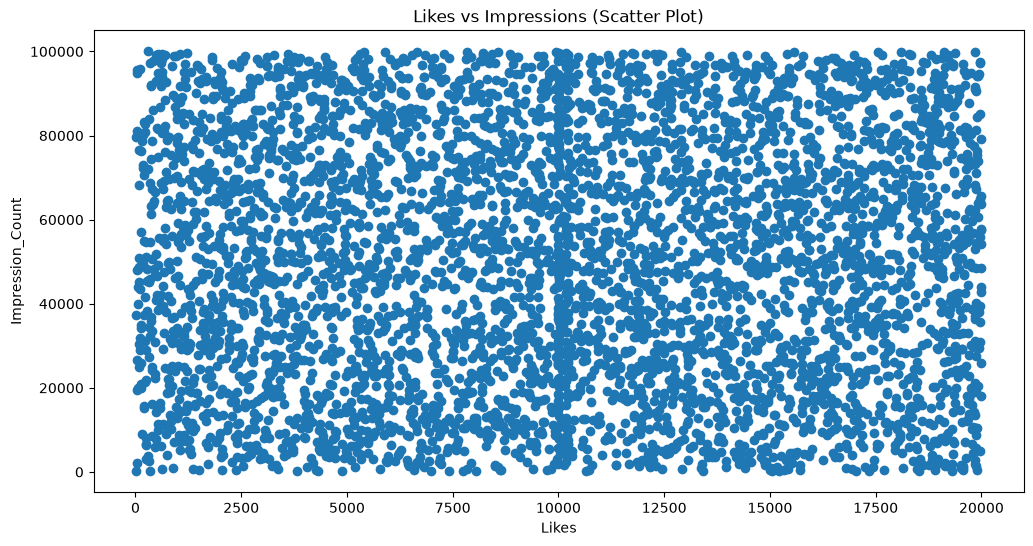

In [139]:
# Scatter: Likes vs impressions
plt.figure(figsize=(12, 6))
plt.scatter(df['Likes'],df['Impression_Count'])
plt.xlabel('Likes')
plt.ylabel('Impression_Count')
plt.title('Likes vs Impressions (Scatter Plot)')
plt.show()

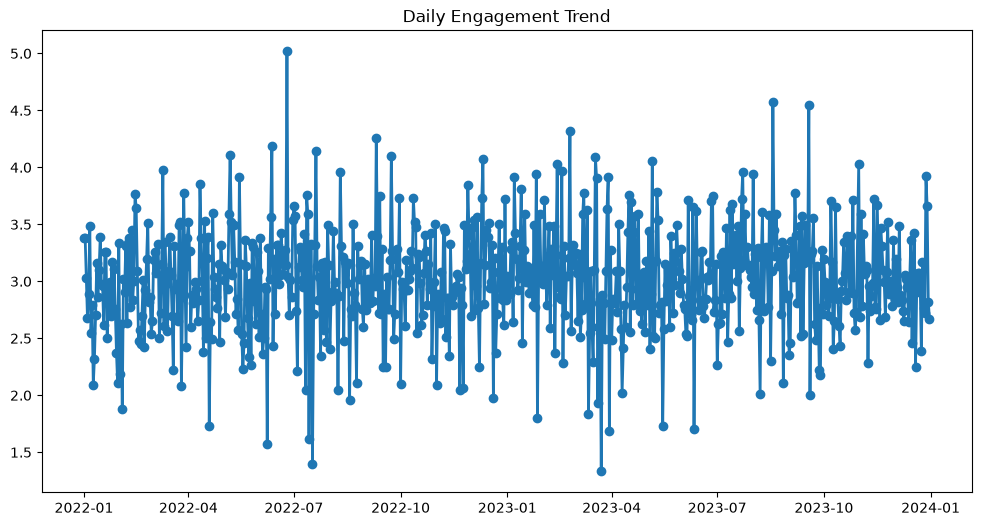

In [141]:
# 2. Line: daily engagement trend
plt.figure(figsize=(12, 6))
daily_trend = df.groupby(df['Posted_At'].dt.date)['Engagement_Score'].mean()
plt.plot(daily_trend.index, daily_trend.values, marker='o', linewidth=2)
plt.title('Daily Engagement Trend')
plt.show()

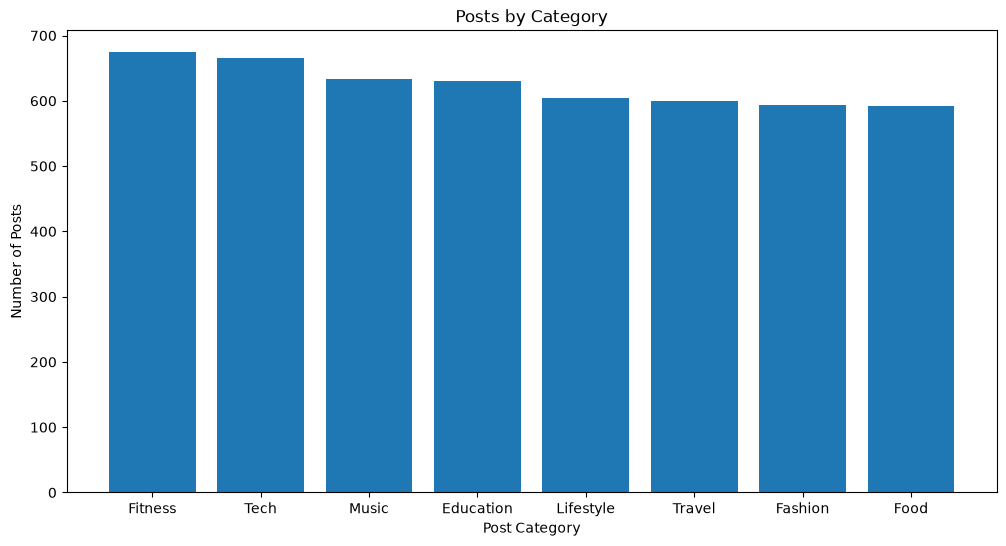

In [142]:
# Bar: posts by category
category_counts = df['Post_Category'].value_counts()
plt.figure(figsize=(12, 6))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')
plt.show()


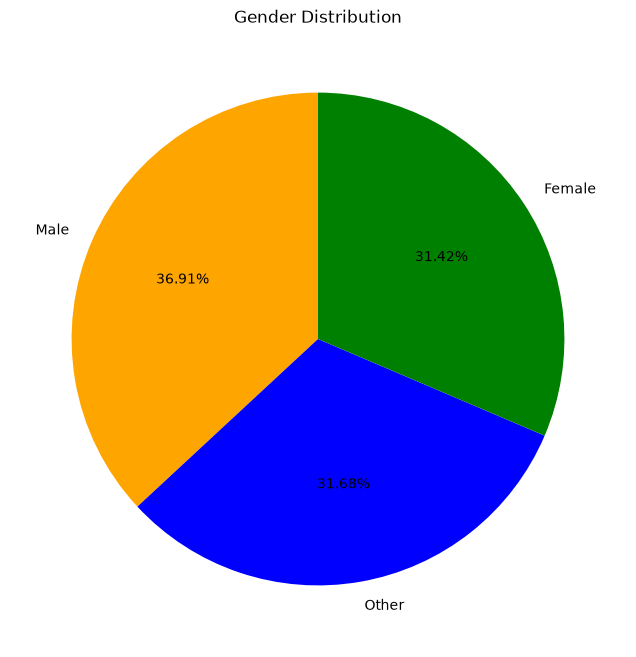

In [146]:
# Pie: Gender distribution
Gender_data = df['Gender'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(Gender_data.values, labels=Gender_data.index, autopct='%0.2f%%', startangle=90, colors=['orange','blue','green'])
plt.title("Gender Distribution")
plt.show()

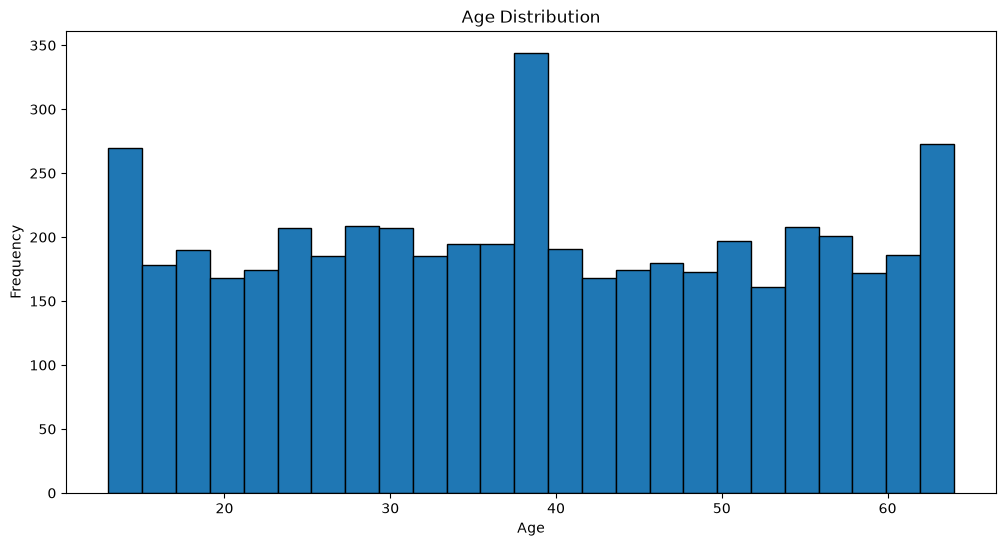

In [147]:
# Histogram: Age
plt.figure(figsize=(12,6))
plt.hist(df['Age'], bins=25, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

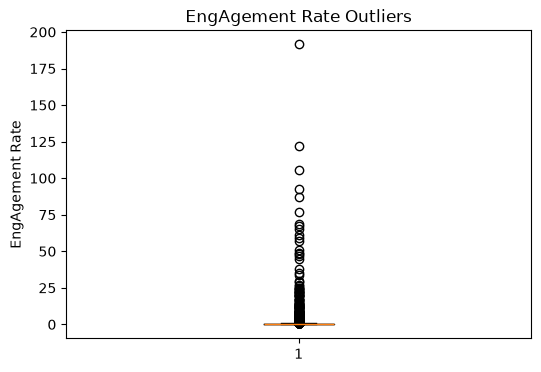

In [148]:
# BOX PLOT: engAgement rate
plt.figure(figsize=(6,4))
plt.boxplot(df['Engagement_Rate'])
plt.title("EngAgement Rate Outliers")
plt.ylabel("EngAgement Rate")
plt.show()
     

## Seaborn

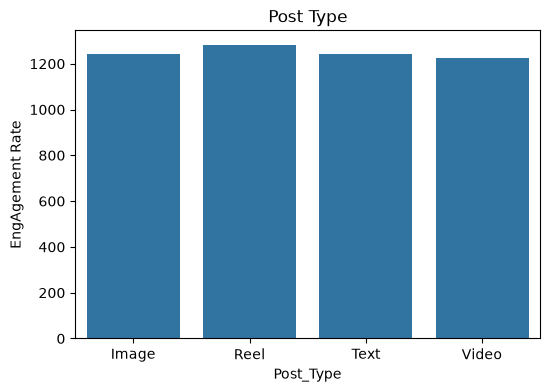

In [152]:
#Count plot: post type
plt.figure(figsize=(6,4))
sns.countplot(x='Post_Type', data=df)
plt.title("Post Type")
plt.ylabel("EngAgement Rate")
plt.show()

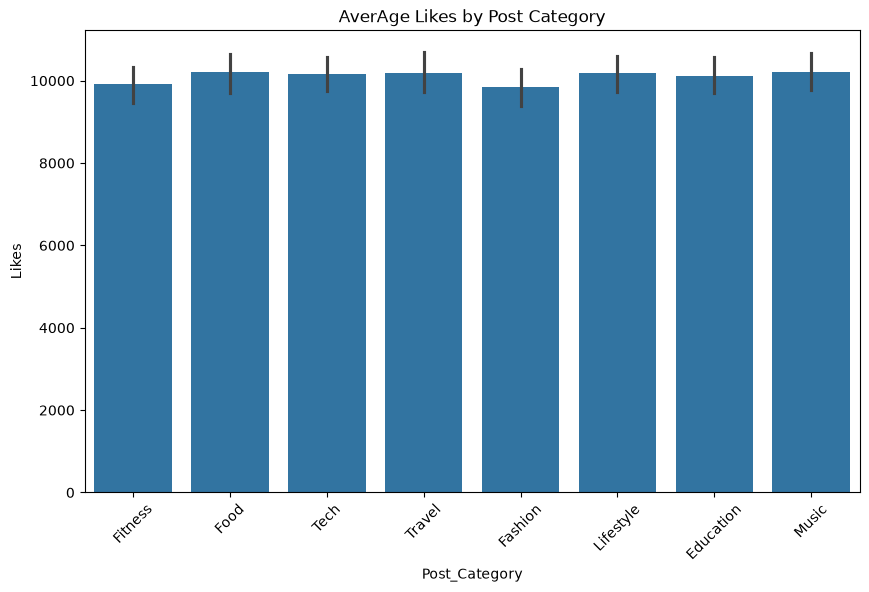

In [153]:

# Bar plot: avg Likes by category
plt.figure(figsize=(10,6))
sns.barplot(x='Post_Category', y='Likes', data=df)
plt.title('AverAge Likes by Post Category')
plt.xticks(rotation=45)
plt.show()

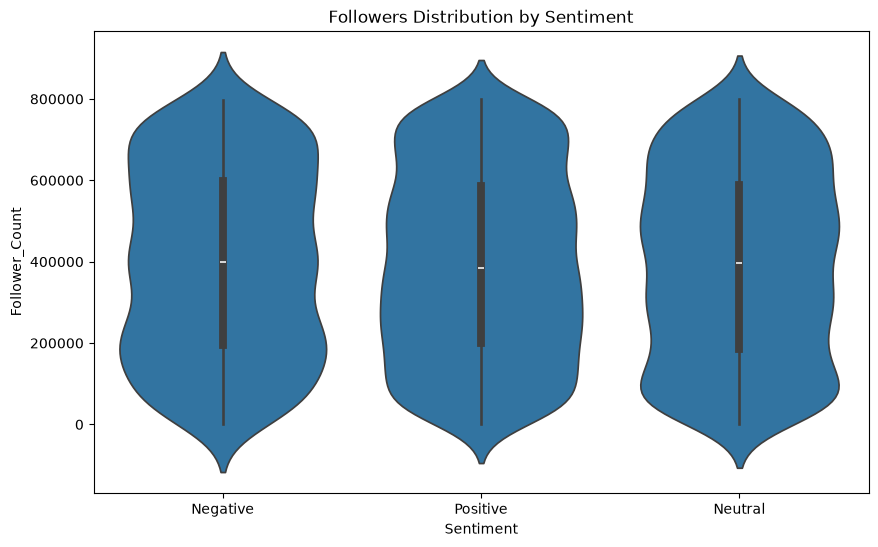

In [154]:
# Violin: followers vs Sentiment
plt.figure(figsize=(10,6))
sns.violinplot(x='Sentiment', y='Follower_Count', data=df)
plt.title('Followers Distribution by Sentiment')
plt.show()


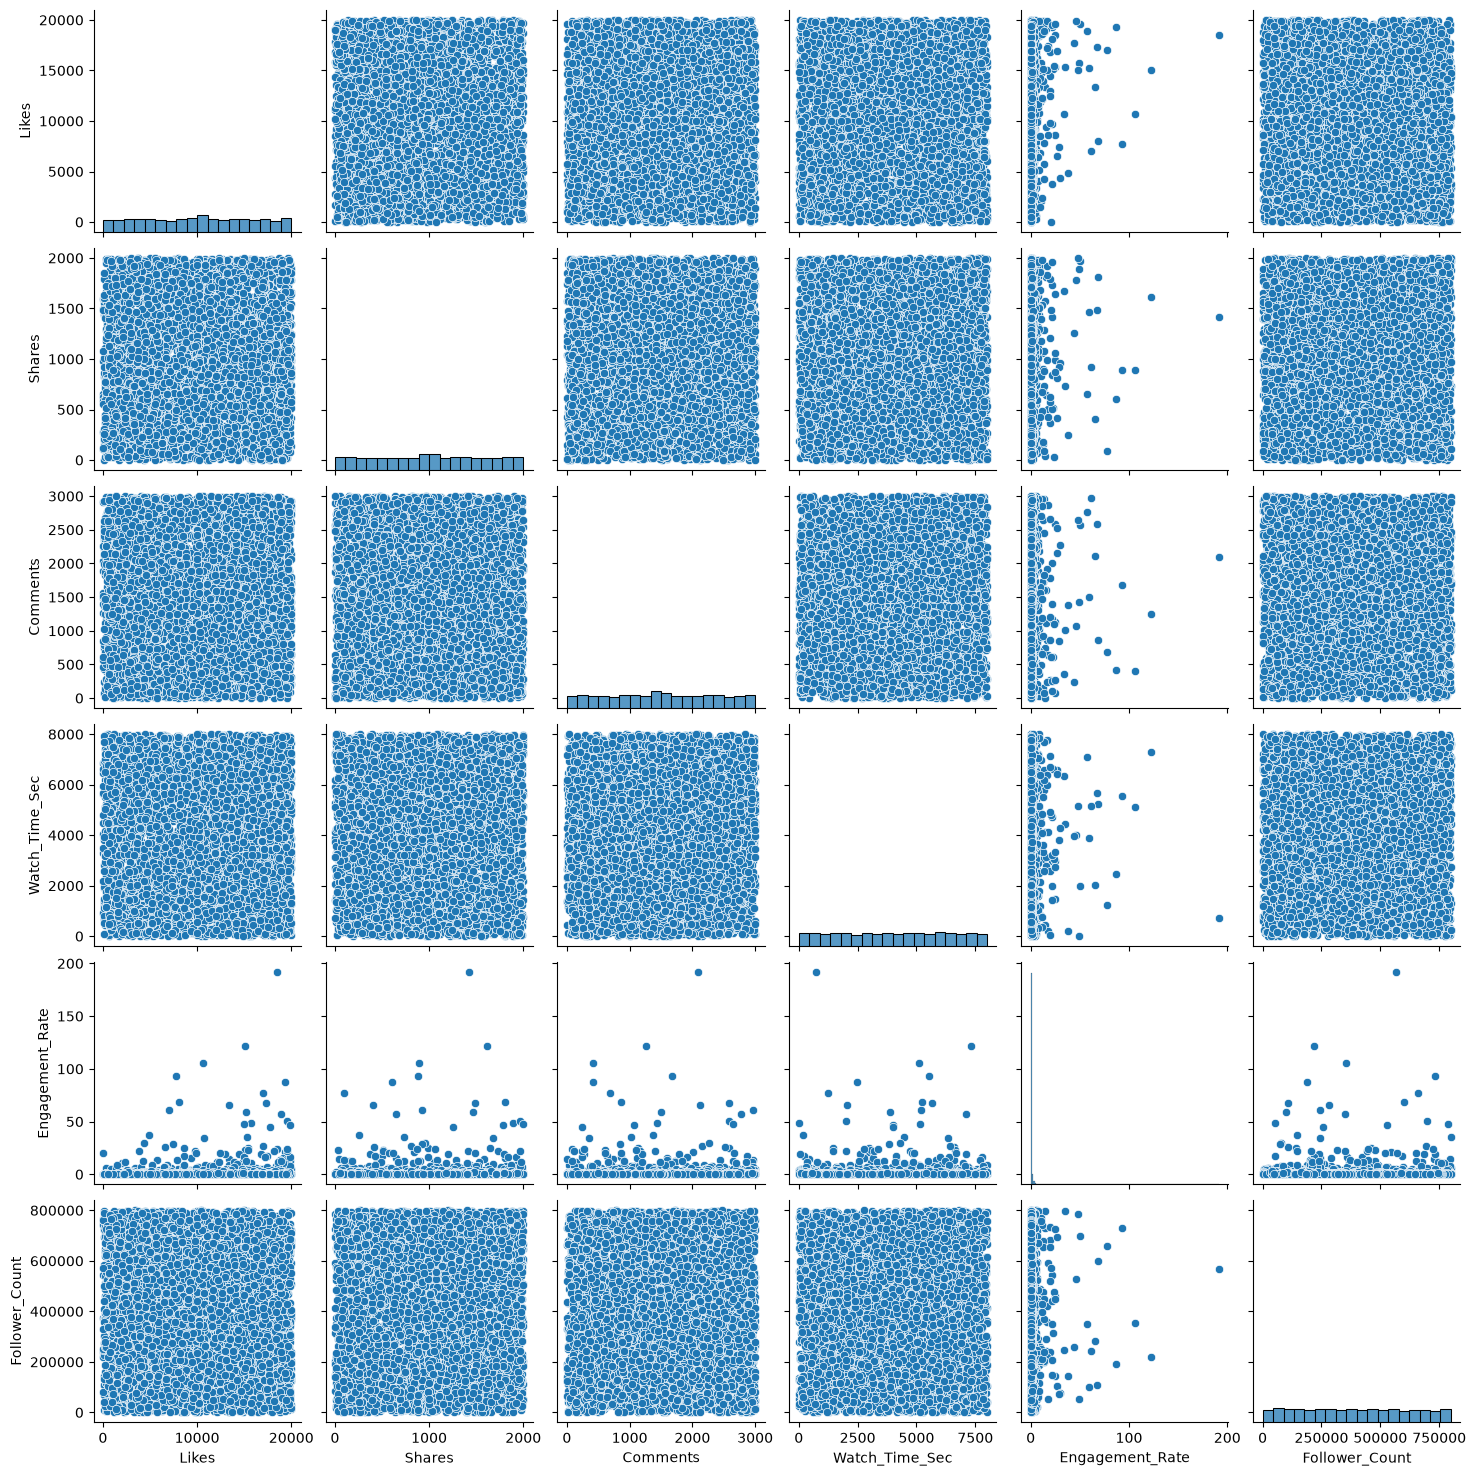

In [157]:
# Pair plot: numeric features

sns.pairplot(df[col])
plt.show()

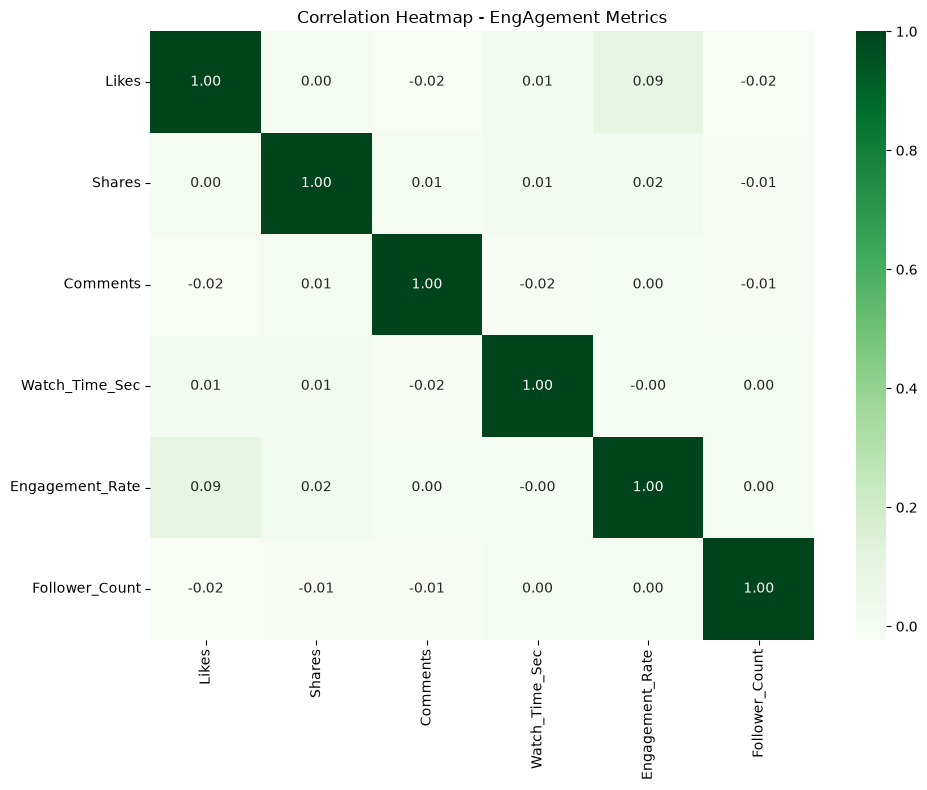

In [159]:
# Heatmap: correlation matrix

plt.figure(figsize=(10,8))
corr_matrix = df[col].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt='.2f')
plt.title('Correlation Heatmap - EngAgement Metrics')
plt.tight_layout()
plt.show()


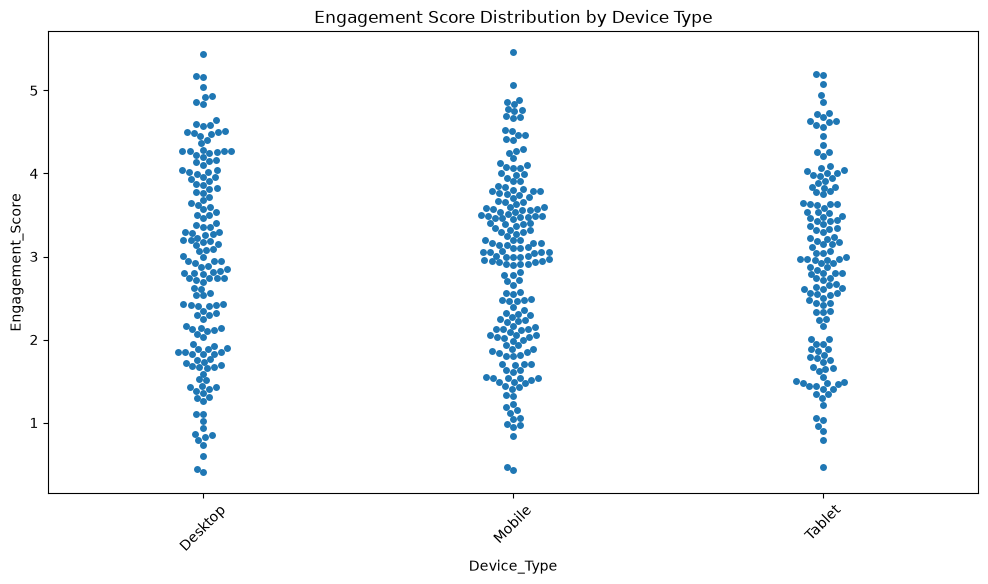

In [161]:
# Swarm plot: engAgement vs device

plt.figure(figsize=(12,6))
sns.swarmplot(x='Device_Type', y='Engagement_Score', data=df.sample(500))
plt.title('Engagement Score Distribution by Device Type')
plt.xticks(rotation=45)
plt.show()

### Plotly (Interactive)

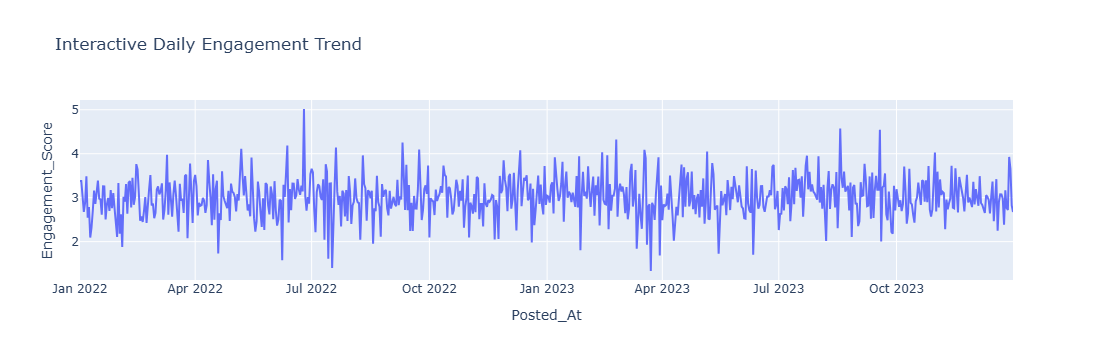

In [163]:
# Interactive line chart
daily_df = daily.reset_index()
fig = px.line(daily_df, x='Posted_At', y='Engagement_Score', title='Interactive Daily Engagement Trend')
fig.show()

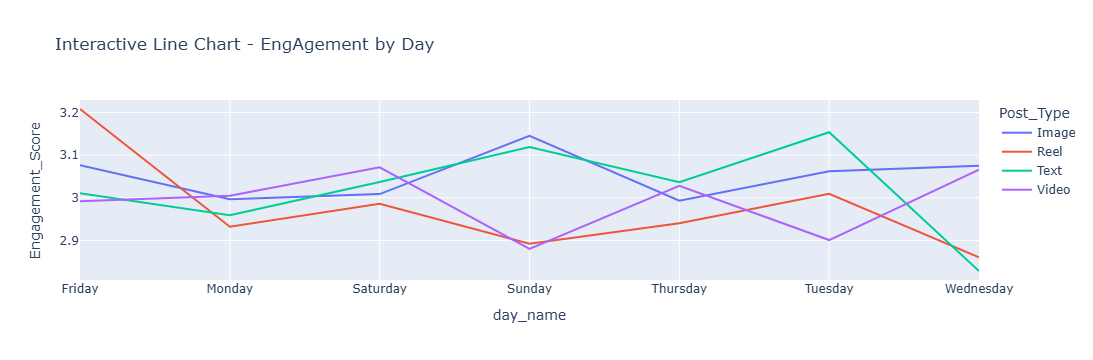

In [165]:
#INTERACTIVE LINE CHART - Daily EngAgement Trend

df['date'] = pd.to_datetime(df['Posted_At'])
df['day_name'] = df['date'].dt.day_name()
daily_engAgement = df.groupby(['day_name', 'Post_Type'])['Engagement_Score'].mean().reset_index()

fig_line = px.line(daily_engAgement, x='day_name', y='Engagement_Score', color='Post_Type', title='Interactive Line Chart - EngAgement by Day')
fig_line.show()


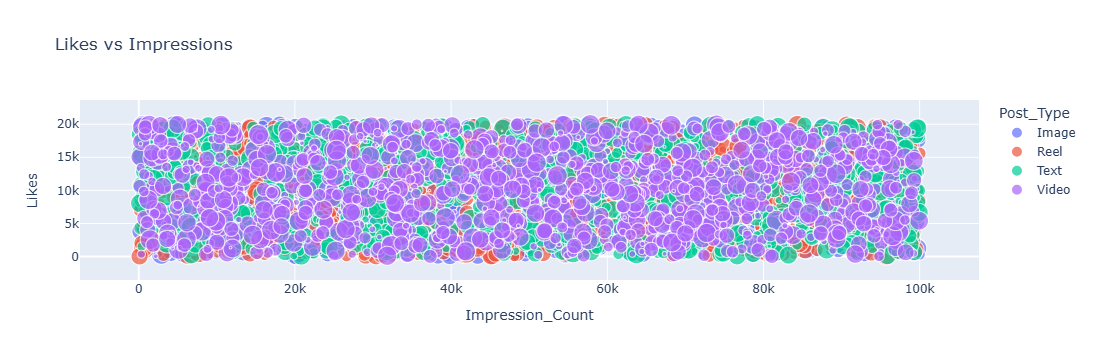

In [166]:
#INTERACTIVE SCATTER CHART - Likes vs Impressions
scatter = px.scatter(df, x='Impression_Count', y='Likes',
                        color='Post_Type', size='Shares',
                        hover_name='Post_Category',
                        title=' Likes vs Impressions')
scatter.show()

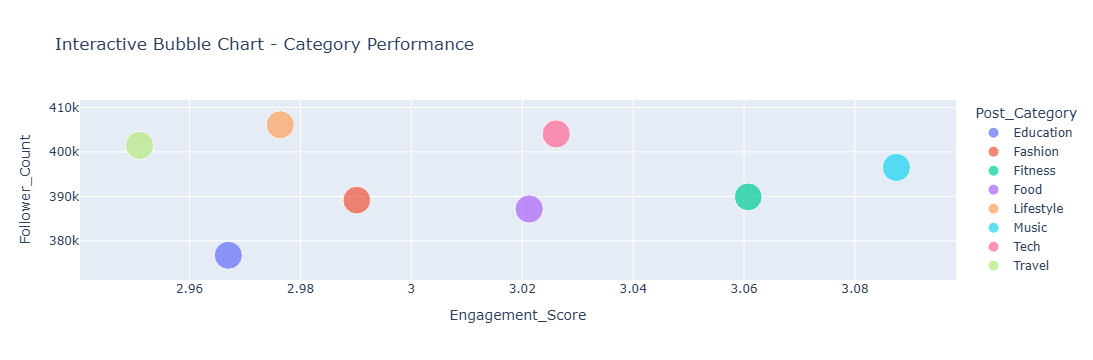

In [168]:
# INTERACTIVE BUBBLE CHART - EngAgement by Category (enhanced scatter)
category_summary = df.groupby('Post_Category').agg({
    'Engagement_Score': 'mean',
    'Follower_Count': 'mean',
    'Likes': 'mean'
}).reset_index()

bubble = px.scatter(category_summary, x='Engagement_Score', y='Follower_Count',
                       size='Likes', color='Post_Category',
                       hover_name='Post_Category',
                       title='Interactive Bubble Chart - Category Performance')
bubble.show()

In [172]:
# Engagement rate by country
df.groupby('Country')['Engagement_Rate'].mean().round(2).sort_values(ascending=False)

Country
Brazil       1.54
Australia    1.33
France       1.15
Uae          1.11
Canada       0.92
Uk           0.85
Japan        0.77
Germany      0.76
India        0.66
Usa          0.58
Name: Engagement_Rate, dtype: float64

In [174]:
# Device vs watch time
df.groupby('Device_Type')['Watch_Time_Sec'].mean().round(1).sort_values(ascending=False)

Device_Type
Mobile     4087.6
Tablet     3980.8
Desktop    3975.8
Name: Watch_Time_Sec, dtype: float64